Bloque practico

In [1]:
//CONFIGURACION ENTORNO
import $ivy.`org.apache.spark::spark-sql:4.1.1`
import $ivy.`org.apache.spark::spark-mllib:4.1.1`

import $ivy.$
import $ivy.$

In [2]:
//CREAR SPARK SESSION
import org.apache.spark.sql.SparkSession
import org.apache.spark.sql.functions._

val spark = SparkSession.builder()
  .master("local[*]")
	  .appName("MLlib-c23")
  .config("spark.ui.enabled", "false")
  .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

println(s"Spark ${spark.version} listo")
// Salida esperada: Spark 4.1.1 listo

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/07 15:30:39 INFO SparkContext: Running Spark version 4.1.1
26/05/07 15:30:39 INFO SparkContext: OS info Windows 11, 10.0, amd64
26/05/07 15:30:39 INFO SparkContext: Java version 17.0.18+8
26/05/07 15:30:39 WARN Shell: Did not find winutils.exe: java.io.FileNotFoundException: java.io.FileNotFoundException: HADOOP_HOME and hadoop.home.dir are unset. -see https://cwiki.apache.org/confluence/display/HADOOP2/WindowsProblems
26/05/07 15:30:39 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/07 15:30:40 INFO ResourceUtils: ==============================================================
26/05/07 15:30:40 INFO ResourceUtils: No custom resources configured for spark.driver.
26/05/07 15:30:40 INFO ResourceUtils: ==============================================================
26/05/07 15:30:40 INFO SparkContext: Submitted application

Spark 4.1.1 listo


import org.apache.spark.sql.SparkSession
import org.apache.spark.sql.functions._
spark: SparkSession = org.apache.spark.sql.classic.SparkSession@6a602de1

In [3]:
//CARGA DE DATASET
import spark.implicits._

val casas = Seq(
  (50.0, 1, 30, 120000.0),
  (65.0, 2, 20, 155000.0),
  (80.0, 3, 10, 210000.0),
  (95.0, 3, 5, 265000.0),
  (110.0, 4, 8, 310000.0),
  (75.0, 2, 15, 190000.0),
  (130.0, 4, 2, 370000.0),
  (60.0, 2, 25, 145000.0),
  (90.0, 3, 12, 240000.0),
  (55.0, 1, 40, 110000.0),
  (100.0, 4, 18, 280000.0),
  (85.0, 3, 7, 225000.0)
).toDF("superficie", "habitaciones", "antiguedad", "precio")

import spark.implicits._
casas: org.apache.spark.sql.package.DataFrame = [superficie: double, habitaciones: int ... 2 more fields]

In [4]:
println("=== Esquema ===")
casas.printSchema()

println("=== Primeras filas ===")
casas.show()

println("=== Estadísticas ===")
casas.describe().show()

=== Esquema ===
root
 |-- superficie: double (nullable = false)
 |-- habitaciones: integer (nullable = false)
 |-- antiguedad: integer (nullable = false)
 |-- precio: double (nullable = false)

=== Primeras filas ===
+----------+------------+----------+--------+
|superficie|habitaciones|antiguedad|  precio|
+----------+------------+----------+--------+
|      50.0|           1|        30|120000.0|
|      65.0|           2|        20|155000.0|
|      80.0|           3|        10|210000.0|
|      95.0|           3|         5|265000.0|
|     110.0|           4|         8|310000.0|
|      75.0|           2|        15|190000.0|
|     130.0|           4|         2|370000.0|
|      60.0|           2|        25|145000.0|
|      90.0|           3|        12|240000.0|
|      55.0|           1|        40|110000.0|
|     100.0|           4|        18|280000.0|
|      85.0|           3|         7|225000.0|
+----------+------------+----------+--------+

=== Estadísticas ===
+-------+----------------

 Aplicar VectorAssembler
Convierte las columnas numéricas en la columna features que necesita MLlib.

In [5]:
import org.apache.spark.ml.feature.VectorAssembler

val assembler = new VectorAssembler()
  .setInputCols(Array("superficie", "habitaciones", "antiguedad"))
  .setOutputCol("features")

import org.apache.spark.ml.feature.VectorAssembler
assembler: VectorAssembler = VectorAssembler: uid=vecAssembler_add3adfe4c44, handleInvalid=error, numInputCols=3

In [6]:
val casasConFeatures = assembler.transform(casas)

casasConFeatures.select("superficie", "habitaciones", "antiguedad", "features", "precio").show(5, truncate = false)

+----------+------------+----------+---------------+--------+
|superficie|habitaciones|antiguedad|features       |precio  |
+----------+------------+----------+---------------+--------+
|50.0      |1           |30        |[50.0,1.0,30.0]|120000.0|
|65.0      |2           |20        |[65.0,2.0,20.0]|155000.0|
|80.0      |3           |10        |[80.0,3.0,10.0]|210000.0|
|95.0      |3           |5         |[95.0,3.0,5.0] |265000.0|
|110.0     |4           |8         |[110.0,4.0,8.0]|310000.0|
+----------+------------+----------+---------------+--------+
only showing top 5 rows


casasConFeatures: org.apache.spark.sql.package.DataFrame = [superficie: double, habitaciones: int ... 3 more fields]

In [7]:
//P3 — Dividir datos y entrenar el modelo
val Array(trainData, testData) = casasConFeatures.randomSplit(Array(0.8, 0.2), seed = 42)

println(s"Filas de entrenamiento: ${trainData.count()}")
println(s"Filas de prueba:        ${testData.count()}")

Filas de entrenamiento: 10
Filas de prueba:        2


trainData: org.apache.spark.sql.Dataset[org.apache.spark.sql.Row] = [superficie: double, habitaciones: int ... 3 more fields]
testData: org.apache.spark.sql.Dataset[org.apache.spark.sql.Row] = [superficie: double, habitaciones: int ... 3 more fields]

In [8]:
import org.apache.spark.ml.regression.LinearRegression

val lr = new LinearRegression()
  .setFeaturesCol("features")
  .setLabelCol("precio")
  .setMaxIter(100)

val model = lr.fit(trainData)

import org.apache.spark.ml.regression.LinearRegression
lr: LinearRegression = linReg_8d1d2086f5bf
model: org.apache.spark.ml.regression.LinearRegressionModel = LinearRegressionModel: uid=linReg_8d1d2086f5bf, numFeatures=3

In [9]:
// Inspeccionar los coeficientes aprendidos
println(s"Coeficientes: ${model.coefficients}")
println(s"Intercept:    ${model.intercept}")

Coeficientes: [2857.659630559311,6285.207997557454,-495.8103905908932]
Intercept:    -26261.428930917165


Interpreta: El primer coeficiente (~2800) indica que cada metro cuadrado extra 
suma aproximadamente 2.800 € al precio. El coeficiente negativo de antigüedad
 indica que a más años, menos precio.

In [10]:
//Hacer predicciones y evaluarlas
val predicciones = model.transform(testData)

predicciones.select("superficie", "habitaciones", "antiguedad", "precio", "prediction").show(truncate = false)

+----------+------------+----------+--------+------------------+
|superficie|habitaciones|antiguedad|precio  |prediction        |
+----------+------------+----------+--------+------------------+
|65.0      |2           |20        |155000.0|162140.65523873508|
|85.0      |3           |7         |225000.0|232024.5909251604 |
+----------+------------+----------+--------+------------------+



predicciones: org.apache.spark.sql.package.DataFrame = [superficie: double, habitaciones: int ... 4 more fields]

In [11]:
import org.apache.spark.ml.evaluation.RegressionEvaluator

val evaluatorRMSE = new RegressionEvaluator()
  .setLabelCol("precio")
  .setPredictionCol("prediction")
  .setMetricName("rmse")

val evaluatorR2 = new RegressionEvaluator()
  .setLabelCol("precio")
  .setPredictionCol("prediction")
  .setMetricName("r2")

val rmse = evaluatorRMSE.evaluate(predicciones)
val r2   = evaluatorR2.evaluate(predicciones)

println(f"RMSE = $rmse%.2f €")
println(f"R²   = $r2%.4f")

RMSE = 7082,86 €
R²   = 0,9590


import org.apache.spark.ml.evaluation.RegressionEvaluator
evaluatorRMSE: RegressionEvaluator = RegressionEvaluator: uid=regEval_a7fc35c9e58c, metricName=rmse, throughOrigin=false
evaluatorR2: RegressionEvaluator = RegressionEvaluator: uid=regEval_3e32fadc5a40, metricName=r2, throughOrigin=false
rmse: Double = 7082.860824000441
r2: Double = 0.9590474143247671

Interpreta el R²: Un valor cercano a 1.0 indica que el modelo explica bien la
 varianza en los precios. Con tan solo 12 filas los resultados son orientativos; 
 en datos reales se necesitan miles de ejemplos.

 Pipeline completo de principio a fin

In [12]:
import org.apache.spark.ml.Pipeline
import org.apache.spark.ml.feature.VectorAssembler
import org.apache.spark.ml.regression.LinearRegression

val assembler2 = new VectorAssembler()
  .setInputCols(Array("superficie", "habitaciones", "antiguedad"))
  .setOutputCol("features")

val lr2 = new LinearRegression()
  .setFeaturesCol("features")
  .setLabelCol("precio")
  .setMaxIter(100)

val pipeline = new Pipeline()
  .setStages(Array(assembler2, lr2))

import org.apache.spark.ml.Pipeline
import org.apache.spark.ml.feature.VectorAssembler
import org.apache.spark.ml.regression.LinearRegression
assembler2: VectorAssembler = VectorAssembler: uid=vecAssembler_bd225735bdff, handleInvalid=error, numInputCols=3
lr2: LinearRegression = linReg_0ddd980ea075
pipeline: Pipeline = pipeline_59e699a195f2

In [13]:
// Partir los datos ANTES del pipeline (sobre el df original sin features)
val Array(train2, test2) = casas.randomSplit(Array(0.8, 0.2), seed = 42)

// Entrenar el pipeline completo
val pipelineModel = pipeline.fit(train2)

// Predecir
val preds2 = pipelineModel.transform(test2)
preds2.select("superficie", "precio", "prediction").show(truncate = false)

+----------+--------+------------------+
|superficie|precio  |prediction        |
+----------+--------+------------------+
|65.0      |155000.0|162140.65523873508|
|85.0      |225000.0|232024.5909251604 |
+----------+--------+------------------+



train2: org.apache.spark.sql.Dataset[org.apache.spark.sql.Row] = [superficie: double, habitaciones: int ... 2 more fields]
test2: org.apache.spark.sql.Dataset[org.apache.spark.sql.Row] = [superficie: double, habitaciones: int ... 2 more fields]
pipelineModel: org.apache.spark.ml.PipelineModel = pipeline_59e699a195f2
preds2: org.apache.spark.sql.package.DataFrame = [superficie: double, habitaciones: int ... 4 more fields]

In [14]:
val evaluator2 = new RegressionEvaluator()
  .setLabelCol("precio")
  .setPredictionCol("prediction")
  .setMetricName("rmse")

val rmse2 = evaluator2.evaluate(preds2)
println(f"RMSE del Pipeline = $rmse2%.2f €")

RMSE del Pipeline = 7082,86 €


evaluator2: RegressionEvaluator = RegressionEvaluator: uid=regEval_daf32b060de1, metricName=rmse, throughOrigin=false
rmse2: Double = 7082.860824000441

 Ventaja del Pipeline: En el ejercicio anterior teníamos que llamar a assembler.transform()
  manualmente sobre trainData y testData por separado. Con el Pipeline, basta con llamar a
   pipeline.fit(train2) y él se encarga de ejecutar todas las etapas en orden, tanto al entrenar
    como al predecir.

 Comparar usando sólo una feature vs todas
¿Cambia mucho el modelo si sólo usamos la superficie en lugar de las tres variables

In [15]:
val assemblerSolo = new VectorAssembler()
  .setInputCols(Array("superficie"))
  .setOutputCol("features")

val lrSolo = new LinearRegression()
  .setFeaturesCol("features")
  .setLabelCol("precio")
  .setMaxIter(100)

val pipelineSolo = new Pipeline()
  .setStages(Array(assemblerSolo, lrSolo))

assemblerSolo: VectorAssembler = VectorAssembler: uid=vecAssembler_38a7c9ed3ec0, handleInvalid=error, numInputCols=1
lrSolo: LinearRegression = linReg_4eacbe17aef4
pipelineSolo: Pipeline = pipeline_a2f139ee78ae

In [16]:
val modelSolo = pipelineSolo.fit(train2)
val predsSolo = modelSolo.transform(test2)

val evaluator3 = new RegressionEvaluator()
  .setLabelCol("precio")
  .setPredictionCol("prediction")
  .setMetricName("rmse")

val rmseSolo = evaluator3.evaluate(predsSolo)
println(f"RMSE con sólo superficie   = $rmseSolo%.2f €")
println(f"RMSE con las 3 variables   = $rmse2%.2f €")

if (rmse2 < rmseSolo)
  println("✅ El modelo con más variables predice mejor")
else
  println("⚠️ Con pocos datos, añadir variables no siempre mejora")

RMSE con sólo superficie   = 3052,14 €
RMSE con las 3 variables   = 7082,86 €
⚠️ Con pocos datos, añadir variables no siempre mejora


modelSolo: org.apache.spark.ml.PipelineModel = pipeline_a2f139ee78ae
predsSolo: org.apache.spark.sql.package.DataFrame = [superficie: double, habitaciones: int ... 4 more fields]
evaluator3: RegressionEvaluator = RegressionEvaluator: uid=regEval_7c3226e04a2c, metricName=rmse, throughOrigin=false
rmseSolo: Double = 3052.141530598224

Caso de Estudio — LogiTrack S.A.
Predicción de Tiempo de Entrega en una Red Logística Nacional
Dos vías de implementación: Local y Azure Databricks
🏢 Contexto empresarial
LogiTrack S.A. es una empresa de logística nacional que gestiona miles de envíos diarios entre almacenes y clientes finales en toda España. El equipo directivo ha detectado que los retrasos en las entregas están generando reclamaciones y penalizaciones contractuales. El Director de Operaciones ha encargado al equipo de datos construir un modelo predictivo que estime el tiempo de entrega (en horas) antes de que el paquete salga del almacén.

Como Ingeniero de datos, implementarás este modelo en dos entornos profesionales distintos que representan dos realidades habituales en la industria.

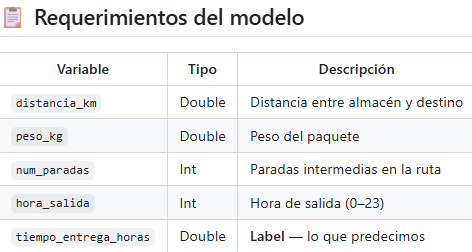

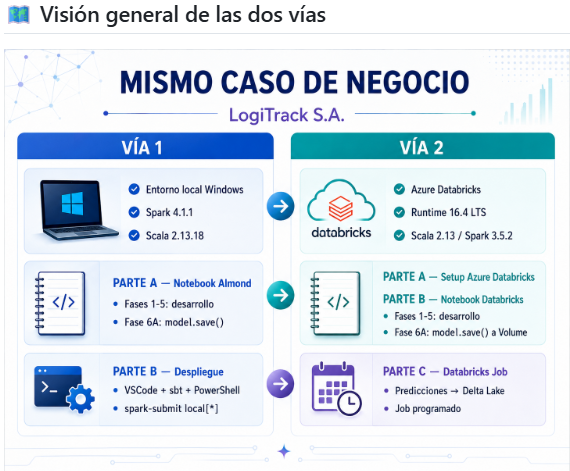

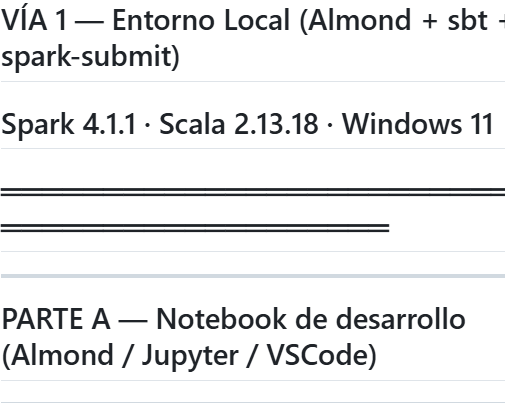

In [1]:
//inicializacion
System.setProperty("hadoop.home.dir", "C:/hadoop")

import $ivy.`org.apache.spark::spark-sql:3.5.1`
import $ivy.`org.apache.spark::spark-mllib:3.5.1`

//sparksession
import org.apache.spark.sql.SparkSession
import org.apache.spark.sql.functions._

val spark = SparkSession.builder()
  .master("local[*]")
  .appName("LogiTrack-V1")
  .config("spark.ui.enabled", "false")
  .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
import spark.implicits._
println(s"Spark ${spark.version} listo")
// Salida esperada: Spark 4.1.1 listo

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/07 16:34:09 INFO SparkContext: Running Spark version 3.5.1
26/05/07 16:34:09 INFO SparkContext: OS info Windows 11, 10.0, amd64
26/05/07 16:34:09 INFO SparkContext: Java version 17.0.18
26/05/07 16:34:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/07 16:34:10 INFO ResourceUtils: ==============================================================
26/05/07 16:34:10 INFO ResourceUtils: No custom resources configured for spark.driver.
26/05/07 16:34:10 INFO ResourceUtils: ==============================================================
26/05/07 16:34:10 INFO SparkContext: Submitted application: LogiTrack-V1
26/05/07 16:34:10 INFO ResourceProfile: Default ResourceProfile created, executor resources: Map(cores -> name: cores, amount: 1, script: , vendor: , memory -> name: memory, amount: 1024, script: , vendor: , offHeap -> nam

Spark 3.5.1 listo


res1_0: String = null
import $ivy.$
import $ivy.$
import org.apache.spark.sql.SparkSession
import org.apache.spark.sql.functions._
spark: SparkSession = org.apache.spark.sql.SparkSession@371911d4
import spark.implicits._

In [2]:
val envios = Seq(
  (120.0,  2.5, 1,  8,  4.2),
  (350.0,  8.0, 3, 14,  9.8),
  ( 80.0,  1.2, 0,  6,  2.9),
  (500.0, 15.0, 4,  7, 14.1),
  (210.0,  4.5, 2, 10,  6.3),
  (430.0, 10.0, 3, 22, 13.0),
  ( 60.0,  0.8, 0,  9,  2.1),
  (300.0,  6.5, 2, 16,  8.7),
  (150.0,  3.0, 1, 11,  4.8),
  (620.0, 18.0, 5,  8, 17.2),
  (240.0,  5.0, 2, 13,  7.1),
  ( 90.0,  1.5, 0, 18,  3.2),
  (410.0,  9.0, 3, 20, 11.9),
  (170.0,  3.5, 1, 15,  5.3),
  (540.0, 12.0, 4,  6, 15.4),
  (280.0,  6.0, 2,  9,  8.0),
  (110.0,  2.0, 1,  7,  3.8),
  (390.0,  9.5, 3, 17, 11.2),
  ( 70.0,  1.0, 0, 12,  2.4),
  (460.0, 11.5, 4, 21, 13.7),
  (200.0,  4.0, 1, 10,  5.9),
  (330.0,  7.5, 2, 14,  9.3),
  (130.0,  2.8, 1,  8,  4.4),
  (570.0, 14.0, 5, 16, 16.1),
  (250.0,  5.5, 2, 11,  7.4),
  ( 95.0,  1.8, 0, 19,  3.4),
  (420.0,  9.8, 3,  7, 12.1),
  (180.0,  3.8, 1, 13,  5.6),
  (490.0, 13.0, 4,  9, 14.6),
  (310.0,  6.8, 2, 15,  8.9),
  (140.0,  2.6, 1, 22,  4.9),
  (380.0,  8.5, 3, 18, 10.8),
  ( 75.0,  1.1, 0,  6,  2.6),
  (550.0, 13.5, 4, 11, 15.8),
  (220.0,  4.8, 2,  8,  6.6),
  (450.0, 10.5, 3, 20, 12.8),
  (100.0,  1.9, 0, 14,  3.5),
  (360.0,  8.2, 3, 16, 10.3),
  (190.0,  4.2, 1,  9,  5.8),
  (610.0, 17.5, 5, 13, 17.0),
  (260.0,  5.8, 2, 10,  7.6),
  (115.0,  2.1, 1, 19,  4.0),
  (440.0, 10.2, 3,  7, 12.4),
  (160.0,  3.2, 1, 12,  5.1),
  (530.0, 12.5, 4, 15, 15.1),
  (290.0,  6.2, 2, 17,  8.4),
  ( 85.0,  1.4, 0, 21,  3.0),
  (400.0,  9.2, 3, 11, 11.5),
  (175.0,  3.6, 1, 14,  5.5),
  (480.0, 11.8, 4, 18, 13.9)
).toDF("distancia_km", "peso_kg", "num_paradas", "hora_salida", "tiempo_entrega_horas")

println(s"Registros cargados: ${envios.count()}")
// Salida esperada: Registros cargados: 50

Registros cargados: 50


envios: org.apache.spark.sql.package.DataFrame = [distancia_km: double, peso_kg: double ... 3 more fields]

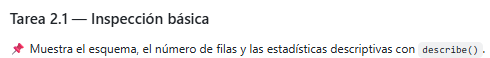

In [3]:
envios.printSchema()

root
 |-- distancia_km: double (nullable = false)
 |-- peso_kg: double (nullable = false)
 |-- num_paradas: integer (nullable = false)
 |-- hora_salida: integer (nullable = false)
 |-- tiempo_entrega_horas: double (nullable = false)



In [4]:
val totalFilas = envios.count()

println(s"Número de filas: $totalFilas")

Número de filas: 50


totalFilas: Long = 50L

In [5]:
envios.describe().show()

+-------+-----------------+-----------------+------------------+------------------+--------------------+
|summary|     distancia_km|          peso_kg|       num_paradas|       hora_salida|tiempo_entrega_horas|
+-------+-----------------+-----------------+------------------+------------------+--------------------+
|  count|               50|               50|                50|                50|                  50|
|   mean|            291.3|            6.766|               2.1|             13.04|               8.588|
| stddev|166.8887262183264|4.614777063622768|1.4880476182856899|4.7593516965473945|   4.527225577389691|
|    min|             60.0|              0.8|                 0|                 6|                 2.1|
|    max|            620.0|             18.0|                 5|                22|                17.2|
+-------+-----------------+-----------------+------------------+------------------+--------------------+



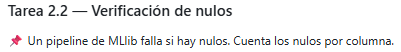

In [6]:
envios.select(
  envios.columns.map(c =>
    sum(when(col(c).isNull, 1).otherwise(0)).alias(c)
  ): _*
).show(false)

1 deprecation (since 2.13.0); re-run enabling -deprecation for details, or try -help


+------------+-------+-----------+-----------+--------------------+
|distancia_km|peso_kg|num_paradas|hora_salida|tiempo_entrega_horas|
+------------+-------+-----------+-----------+--------------------+
|0           |0      |0          |0          |0                   |
+------------+-------+-----------+-----------+--------------------+



In [7]:
//en ML null no es iguan a Nan evaluamos ambos
envios.select(
  envios.columns.map(c =>
    sum(
      when(col(c).isNull || isnan(col(c)), 1).otherwise(0)
    ).alias(c)
  ): _*
).show(false)

1 deprecation (since 2.13.0); re-run enabling -deprecation for details, or try -help


+------------+-------+-----------+-----------+--------------------+
|distancia_km|peso_kg|num_paradas|hora_salida|tiempo_entrega_horas|
+------------+-------+-----------+-----------+--------------------+
|0           |0      |0          |0          |0                   |
+------------+-------+-----------+-----------+--------------------+



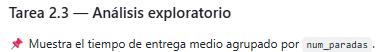

In [8]:
envios
  .groupBy("num_paradas")
  .agg(
    avg("tiempo_entrega_horas").alias("tiempo_medio_entrega")
  )
  .orderBy("num_paradas")
  .show(false)

+-----------+--------------------+
|num_paradas|tiempo_medio_entrega|
+-----------+--------------------+
|0          |2.8875              |
|1          |4.941666666666666   |
|2          |7.830000000000001   |
|3          |11.580000000000002  |
|4          |14.657142857142858  |
|5          |16.766666666666666  |
+-----------+--------------------+



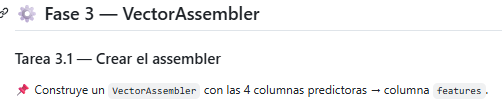

In [9]:
import org.apache.spark.ml.feature.VectorAssembler

val assembler = new VectorAssembler()
  .setInputCols(Array(
    "distancia_km",
    "peso_kg",
    "num_paradas",
    "hora_salida"
  ))
  .setOutputCol("features")

import org.apache.spark.ml.feature.VectorAssembler
assembler: VectorAssembler = VectorAssembler: uid=vecAssembler_67f371ee4136, handleInvalid=error, numInputCols=4

In [10]:
//se aplica
val enviosFeatures = assembler.transform(envios)

enviosFeatures.select(
  "features",
  "tiempo_entrega_horas"
).show(5)

+--------------------+--------------------+
|            features|tiempo_entrega_horas|
+--------------------+--------------------+
| [120.0,2.5,1.0,8.0]|                 4.2|
|[350.0,8.0,3.0,14.0]|                 9.8|
|  [80.0,1.2,0.0,6.0]|                 2.9|
|[500.0,15.0,4.0,7.0]|                14.1|
|[210.0,4.5,2.0,10.0]|                 6.3|
+--------------------+--------------------+
only showing top 5 rows



enviosFeatures: org.apache.spark.sql.package.DataFrame = [distancia_km: double, peso_kg: double ... 4 more fields]

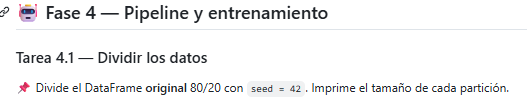

In [11]:
val Array(train, test) = envios.randomSplit(
  Array(0.8, 0.2),
  seed = 42
)

train: org.apache.spark.sql.Dataset[org.apache.spark.sql.Row] = [distancia_km: double, peso_kg: double ... 3 more fields]
test: org.apache.spark.sql.Dataset[org.apache.spark.sql.Row] = [distancia_km: double, peso_kg: double ... 3 more fields]

In [12]:
println(s"Filas entrenamiento: ${train.count()}")
println(s"Filas test: ${test.count()}")
println(s"Total: ${train.count() + test.count()}")

Filas entrenamiento: 41
Filas test: 9
Total: 50


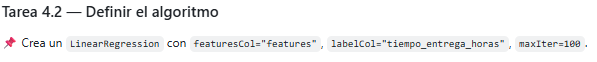

In [13]:
import org.apache.spark.ml.regression.LinearRegression
val lr = new LinearRegression()
  .setFeaturesCol("features")
  .setLabelCol("tiempo_entrega_horas")
  .setMaxIter(100)

import org.apache.spark.ml.regression.LinearRegression
lr: LinearRegression = linReg_0afeebae3975

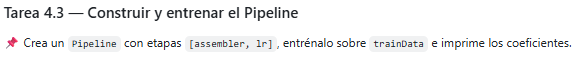

In [14]:
import org.apache.spark.ml.Pipeline
import org.apache.spark.ml.regression.LinearRegressionModel

val pipeline = new Pipeline()
  .setStages(Array(assembler, lr))

val pipelineModel = pipeline.fit(train)

val lrModel = pipelineModel.stages(1).asInstanceOf[LinearRegressionModel]

println(s"Coeficientes: ${lrModel.coefficients}")
println(s"Intercepto: ${lrModel.intercept}")

Coeficientes: [0.02604797872129211,-0.015170306076117857,0.1713325363186,0.014312665374928037]
Intercepto: 0.5761506834189094


import org.apache.spark.ml.Pipeline
import org.apache.spark.ml.regression.LinearRegressionModel
pipeline: Pipeline = pipeline_25b9ef6cdf58
pipelineModel: org.apache.spark.ml.PipelineModel = pipeline_25b9ef6cdf58
lrModel: LinearRegressionModel = LinearRegressionModel: uid=linReg_0afeebae3975, numFeatures=4

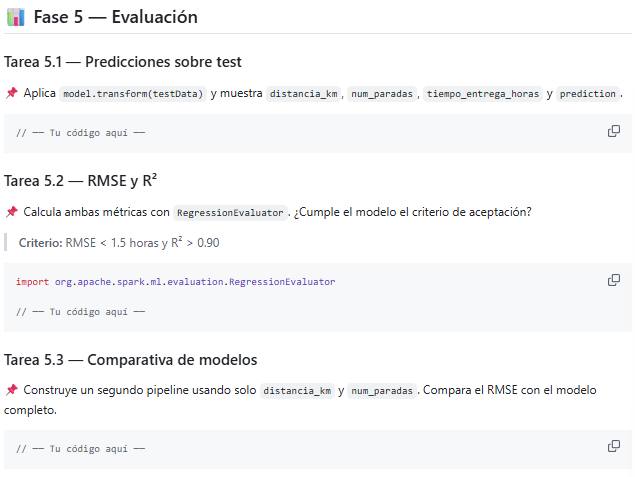

In [15]:
val predicciones = pipelineModel.transform(test)

predicciones
  .select("distancia_km", "num_paradas", "tiempo_entrega_horas", "prediction")
  .show(false)

+------------+-----------+--------------------+------------------+
|distancia_km|num_paradas|tiempo_entrega_horas|prediction        |
+------------+-----------+--------------------+------------------+
|350.0       |3          |9.8                 |10.285955711466997|
|210.0       |2          |6.3                 |6.463751563934202 |
|150.0       |1          |4.8                 |4.76660842882718  |
|390.0       |3          |11.2                |11.348057397329288|
|330.0       |2          |9.3                 |9.601248753760613 |
|100.0       |0          |3.5                 |3.352502289252489 |
|115.0       |1          |4.0                 |3.983083772049887 |
|260.0       |2          |7.6                 |7.746429102099854 |
|160.0       |1          |5.1                 |5.038366820199806 |
+------------+-----------+--------------------+------------------+



predicciones: org.apache.spark.sql.package.DataFrame = [distancia_km: double, peso_kg: double ... 5 more fields]

In [16]:
import org.apache.spark.ml.evaluation.RegressionEvaluator

val evaluatorRMSE = new RegressionEvaluator()
  .setLabelCol("tiempo_entrega_horas")
  .setPredictionCol("prediction")
  .setMetricName("rmse")

val evaluatorR2 = new RegressionEvaluator()
  .setLabelCol("tiempo_entrega_horas")
  .setPredictionCol("prediction")
  .setMetricName("r2")

val rmse = evaluatorRMSE.evaluate(predicciones)
val r2 = evaluatorR2.evaluate(predicciones)

println(s"RMSE: $rmse")
println(s"R2: $r2")

if (rmse < 1.5 && r2 > 0.90)
  println("El modelo cumple el criterio de aceptación")
else
  println("El modelo NO cumple el criterio de aceptación")
  

RMSE: 0.2170602051679045
R2: 0.9930602164931805
El modelo cumple el criterio de aceptación


import org.apache.spark.ml.evaluation.RegressionEvaluator
evaluatorRMSE: RegressionEvaluator = RegressionEvaluator: uid=regEval_b0f19b57e9cf, metricName=rmse, throughOrigin=false
evaluatorR2: RegressionEvaluator = RegressionEvaluator: uid=regEval_a8f90136ed0e, metricName=r2, throughOrigin=false
rmse: Double = 0.2170602051679045
r2: Double = 0.9930602164931805

In [17]:
import org.apache.spark.ml.Pipeline
import org.apache.spark.ml.feature.VectorAssembler
import org.apache.spark.ml.regression.LinearRegression

val assemblerReducido = new VectorAssembler()
  .setInputCols(Array("distancia_km", "num_paradas"))
  .setOutputCol("features")

val lrReducido = new LinearRegression()
  .setFeaturesCol("features")
  .setLabelCol("tiempo_entrega_horas")
  .setMaxIter(100)

val pipelineReducido = new Pipeline()
  .setStages(Array(assemblerReducido, lrReducido))

val modelReducido = pipelineReducido.fit(train)

val prediccionesReducidas = modelReducido.transform(test)

val rmseReducido = evaluatorRMSE.evaluate(prediccionesReducidas)

println(s"RMSE modelo completo: $rmse")
println(s"RMSE modelo reducido: $rmseReducido")

if (rmse < rmseReducido)
  println("El modelo completo funciona mejor")
else
  println("El modelo reducido funciona mejor o igual")

RMSE modelo completo: 0.2170602051679045
RMSE modelo reducido: 0.2125305299160782
El modelo reducido funciona mejor o igual


import org.apache.spark.ml.Pipeline
import org.apache.spark.ml.feature.VectorAssembler
import org.apache.spark.ml.regression.LinearRegression
assemblerReducido: VectorAssembler = VectorAssembler: uid=vecAssembler_ab32d9ffbad6, handleInvalid=error, numInputCols=2
lrReducido: LinearRegression = linReg_aa47a573947c
pipelineReducido: Pipeline = pipeline_b80a64ebaa90
modelReducido: org.apache.spark.ml.PipelineModel = pipeline_b80a64ebaa90
prediccionesReducidas: org.apache.spark.sql.package.DataFrame = [distancia_km: double, peso_kg: double ... 5 more fields]
rmseReducido: Double = 0.2125305299160782

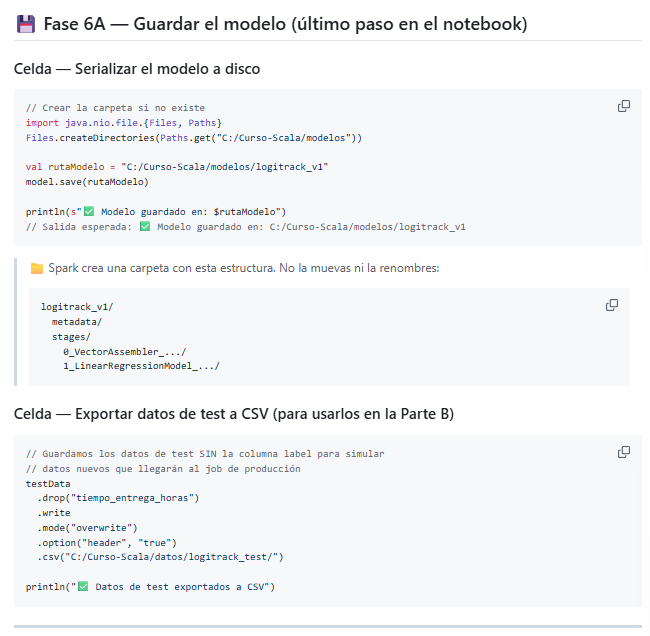

In [18]:
import java.nio.file.{Files, Paths}

Files.createDirectories(Paths.get("C:/temp"))

import java.nio.file.{Files, Paths}
res18_1: java.nio.file.Path = C:\temp

In [22]:
import java.io._

val rutaParams = "C:/temp/logitrack_params.txt"

val writer = new PrintWriter(new File(rutaParams))

writer.println(lrModel.coefficients.toArray.mkString(","))
writer.println(lrModel.intercept)

writer.close()

println(s"✅ Parámetros guardados en: $rutaParams")

✅ Parámetros guardados en: C:/temp/logitrack_params.txt


import java.io._
rutaParams: String = "C:/temp/logitrack_params.txt"
writer: PrintWriter = java.io.PrintWriter@4b1a1079

In [23]:
import scala.io.Source

val rutaParams = "C:/temp/logitrack_params.txt"

val lineas = Source.fromFile(rutaParams).getLines().toArray

val coeficientes = lineas(0).split(",").map(_.toDouble)
val intercepto = lineas(1).toDouble

println(coeficientes.mkString(", "))
println(intercepto)

0.02604797872129211, -0.015170306076117857, 0.1713325363186, 0.014312665374928037
0.5761506834189094


import scala.io.Source
rutaParams: String = "C:/temp/logitrack_params.txt"
lineas: Array[String] = Array(
  "0.02604797872129211,-0.015170306076117857,0.1713325363186,0.014312665374928037",
  "0.5761506834189094"
)
coeficientes: Array[Double] = Array(
  0.02604797872129211,
  -0.015170306076117857,
  0.1713325363186,
  0.014312665374928037
)
intercepto: Double = 0.5761506834189094

In [24]:
import org.apache.spark.sql.functions._

val predecir = udf { 
  (distancia: Double, peso: Double, paradas: Int, hora: Int) =>

    intercepto +
    coeficientes(0) * distancia +
    coeficientes(1) * peso +
    coeficientes(2) * paradas +
    coeficientes(3) * hora
}

val prediccionesManual = test
  .withColumn(
    "prediction",
    predecir(
      col("distancia_km"),
      col("peso_kg"),
      col("num_paradas"),
      col("hora_salida")
    )
  )

prediccionesManual
  .select("distancia_km", "num_paradas", "tiempo_entrega_horas", "prediction")
  .show(false)

+------------+-----------+--------------------+------------------+
|distancia_km|num_paradas|tiempo_entrega_horas|prediction        |
+------------+-----------+--------------------+------------------+
|350.0       |3          |9.8                 |10.285955711466997|
|210.0       |2          |6.3                 |6.463751563934202 |
|150.0       |1          |4.8                 |4.76660842882718  |
|390.0       |3          |11.2                |11.348057397329288|
|330.0       |2          |9.3                 |9.601248753760613 |
|100.0       |0          |3.5                 |3.352502289252489 |
|115.0       |1          |4.0                 |3.9830837720498873|
|260.0       |2          |7.6                 |7.746429102099854 |
|160.0       |1          |5.1                 |5.038366820199806 |
+------------+-----------+--------------------+------------------+



import org.apache.spark.sql.functions._
predecir: org.apache.spark.sql.expressions.UserDefinedFunction = SparkUserDefinedFunction(
  f = ammonite.$sess.cmd24$Helper$$Lambda$9266/0x000001f39ba356c0@19ed5db4,
  dataType = DoubleType,
  inputEncoders = List(
    Some(
      value = ExpressionEncoder(
        objSerializer = BoundReference(
          ordinal = 0,
          dataType = DoubleType,
          nullable = false
        ),
        objDeserializer = AssertNotNull(
          child = UpCast(
            child = GetColumnByOrdinal(ordinal = 0, dataType = DoubleType),
            target = DoubleType,
            walkedTypePath = List("- root class: \"double\"")
          ),
          walkedTypePath = List("- root class: \"double\"")
        ),
        clsTag = Double
      )
    ),
    Some(
      value = ExpressionEncoder(
        objSerializer = BoundReference(
          ordinal = 0,
          dataType = DoubleType,
          nullable = false
        ),
        objDeserializer = Ass

In [26]:
import java.io._

val rutaCsv = "C:/temp/logitrack_test.csv"

val filas = test
  .drop("tiempo_entrega_horas")
  .collect()

val writer = new PrintWriter(new File(rutaCsv))

writer.println("distancia_km,peso_kg,num_paradas,hora_salida")

filas.foreach { row =>
  writer.println(
    s"${row.getAs[Double]("distancia_km")}," +
    s"${row.getAs[Double]("peso_kg")}," +
    s"${row.getAs[Int]("num_paradas")}," +
    s"${row.getAs[Int]("hora_salida")}"
  )
}

writer.close()

println(s"✅ CSV exportado en: $rutaCsv")

✅ CSV exportado en: C:/temp/logitrack_test.csv


import java.io._
rutaCsv: String = "C:/temp/logitrack_test.csv"
filas: Array[org.apache.spark.sql.Row] = Array(
  [350.0,8.0,3,14],
  [210.0,4.5,2,10],
  [150.0,3.0,1,11],
  [390.0,9.5,3,17],
  [330.0,7.5,2,14],
  [100.0,1.9,0,14],
  [115.0,2.1,1,19],
  [260.0,5.8,2,10],
  [160.0,3.2,1,12]
)
writer: PrintWriter = java.io.PrintWriter@6c7663fb